## 1. Imports

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
import psycopg2
from dotenv import load_dotenv
import os
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier





In [39]:
# load data from postgresql database
load_dotenv()

conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    sslmode="require"
)

cur = conn.cursor()


In [40]:
df = pd.read_sql("SELECT * FROM patients;", conn)

In [41]:
df.shape

(54966, 10)

In [42]:

print(df.dtypes)



id                            int64
age                           int64
gender                          str
blood_type                      str
medical_condition               str
admission_type                  str
medication                      str
billing_amount              float64
test_results                    str
created_at           datetime64[us]
dtype: object


In [43]:
print(df[["age", "billing_amount"]].describe().round(2))

            age  billing_amount
count  54966.00        54966.00
mean      51.54        25546.24
std       19.61        14204.92
min       13.00            9.24
25%       35.00        13243.72
50%       52.00        25542.75
75%       68.00        37819.86
max       89.00        52764.28


In [44]:
# check the billing column for negative values
print(df[df["billing_amount"] < 0])

Empty DataFrame
Columns: [id, age, gender, blood_type, medical_condition, admission_type, medication, billing_amount, test_results, created_at]
Index: []


In [45]:
# FIX THE NEGATIVE BILLING 
df["billing_amount"] = df["billing_amount"].abs()

In [46]:
# check if there are any more negative values
print(df[df["billing_amount"] < 0])

Empty DataFrame
Columns: [id, age, gender, blood_type, medical_condition, admission_type, medication, billing_amount, test_results, created_at]
Index: []


In [47]:
# current columns
df.columns.tolist()


['id',
 'age',
 'gender',
 'blood_type',
 'medical_condition',
 'admission_type',
 'medication',
 'billing_amount',
 'test_results',
 'created_at']

## 4. Define features & target

In [48]:
# define the target variable and features
X = df.drop("test_results", axis=1)
y = df["test_results"]

In [49]:


df["billing_amount"] = df["billing_amount"].abs()

BINARY   = ["gender"]
ORDINAL  = ["blood_type", "admission_type"]
NOMINAL  = ["medical_condition", "medication"]
NUMERIC  = ["age", "billing_amount"]

TARGET_CLASSES = ["Normal", "Abnormal", "Inconclusive"]
X = df[BINARY + ORDINAL + NOMINAL + NUMERIC]
y = df["test_results"].map({c: i for i, c in enumerate(TARGET_CLASSES)}).values

preprocessor = ColumnTransformer([
    ("bin", OrdinalEncoder(), BINARY),
    ("ord", OrdinalEncoder(), ORDINAL),
    ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL),
    ("num", StandardScaler(), NUMERIC),
])

X_processed = preprocessor.fit_transform(X)
print(f"Feature matrix: {X_processed.shape} ✓")

Feature matrix: (54966, 16) ✓


In [50]:
df_check = df[["age", "billing_amount", "test_results"]].copy()
df_check["test_results"] = df_check["test_results"].map({"Normal":0,"Abnormal":1,"Inconclusive":2})
print(df_check.corr().round(3))

                  age  billing_amount  test_results
age             1.000          -0.003         0.007
billing_amount -0.003           1.000         0.005
test_results    0.007           0.005         1.000


In [51]:
# correlation 
df_check = df.copy()
df_check["test_results"] = df_check["test_results"].map({"Normal":0,"Abnormal":1,"Inconclusive":2})
df_check["gender"] = df_check["gender"].map({"Male":0,"Female":1})
df_check["admission_type"] = df_check["admission_type"].map({"Urgent":0,"Elective":1,"Emergency":2})
df_check["medical_condition"] = df_check["medical_condition"].map({"Cancer":0,"Diabetes":1,"Obesity":2,"Asthma":3,"Hypertension":4,"Arthritis":5})
df_check["medication"] = df_check["medication"].map({"Aspirin":0,"Ibuprofen":1,"Paracetamol":2,"Penicillin":3,"Lipitor":4})
df_check["blood_type"] = df_check["blood_type"].map({"A+":0,"A-":1,"B+":2,"B-":3,"AB+":4,"AB-":5,"O+":6,"O-":7})

df_check = df_check.drop(columns=["id", "created_at"])
print(df_check.corr().round(3))

                     age  gender  blood_type  medical_condition  \
age                1.000   0.003      -0.001              0.002   
gender             0.003   1.000       0.003              0.001   
blood_type        -0.001   0.003       1.000              0.007   
medical_condition  0.002   0.001       0.007              1.000   
admission_type    -0.002   0.013       0.002              0.004   
medication        -0.009  -0.006       0.004             -0.008   
billing_amount    -0.003  -0.005       0.000              0.004   
test_results       0.007   0.006      -0.006              0.001   

                   admission_type  medication  billing_amount  test_results  
age                        -0.002      -0.009          -0.003         0.007  
gender                      0.013      -0.006          -0.005         0.006  
blood_type                  0.002       0.004           0.000        -0.006  
medical_condition           0.004      -0.008           0.004         0.001  
admiss

In [52]:

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape} ✓")

Train: (43972, 16) | Test: (10994, 16) ✓


In [53]:
# Train a XGBoost classifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=15,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [54]:
#evaluate
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f} ✓")
print("Classification Report:")
print(classification_report(y_test, preds, target_names=TARGET_CLASSES))

Test Accuracy: 0.4012 ✓
Classification Report:
              precision    recall  f1-score   support

      Normal       0.40      0.40      0.40      3666
    Abnormal       0.40      0.40      0.40      3688
Inconclusive       0.40      0.40      0.40      3640

    accuracy                           0.40     10994
   macro avg       0.40      0.40      0.40     10994
weighted avg       0.40      0.40      0.40     10994



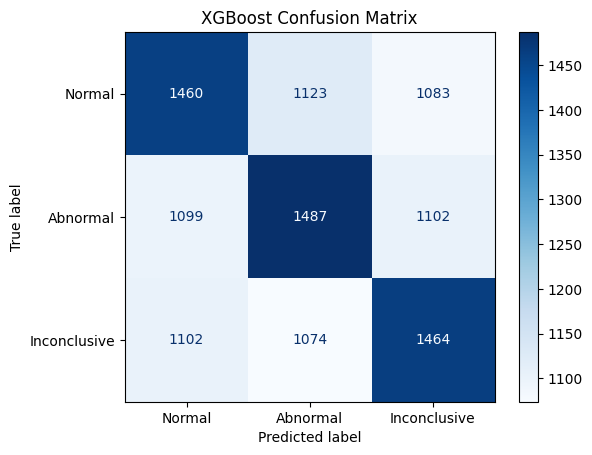

In [55]:
# evaluate using confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

ConfusionMatrixDisplay(cm, display_labels=["Normal", "Abnormal", "Inconclusive"]).plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [56]:
import joblib

# XGBoost model — use native save
model.save_model("xgboost_model.json")

# Preprocessor — keep joblib
joblib.dump(preprocessor, "preprocessor.joblib")

['preprocessor.joblib']

In [57]:
# Train a Random Forest classifier
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [58]:
# Evaluate the model
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
f1  = f1_score(y_test, preds, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print()
print(classification_report(y_test, preds, target_names=TARGET_CLASSES))

Accuracy : 0.3995
F1 Score : 0.3995

              precision    recall  f1-score   support

      Normal       0.40      0.40      0.40      3666
    Abnormal       0.40      0.40      0.40      3688
Inconclusive       0.39      0.40      0.40      3640

    accuracy                           0.40     10994
   macro avg       0.40      0.40      0.40     10994
weighted avg       0.40      0.40      0.40     10994

